In [ ]:
# Add latitude and longitude mapping for cities
city_coordinates = {
    "Ahmedabad": {"Latitude": 23.0225, "Longitude": 72.5714},
    "Chennai": {"Latitude": 13.0827, "Longitude": 80.2707},
    "Ludhiana": {"Latitude": 30.9010, "Longitude": 75.8573},
    "Pune": {"Latitude": 18.5204, "Longitude": 73.8567},
    "Delhi": {"Latitude": 28.7041, "Longitude": 77.1025},
    "Mumbai": {"Latitude": 19.0760, "Longitude": 72.8777},
    "Surat": {"Latitude": 21.1702, "Longitude": 72.8311},
    "Visakhapatnam": {"Latitude": 17.6868, "Longitude": 83.2185},
    "Bangalore": {"Latitude": 12.9716, "Longitude": 77.5946},
    "Kolkata": {"Latitude": 22.5726, "Longitude": 88.3639},
    "Ghaziabad": {"Latitude": 28.6692, "Longitude": 77.4538},
    "Jaipur": {"Latitude": 26.9124, "Longitude": 75.7873},
    "Lucknow": {"Latitude": 26.8467, "Longitude": 80.9462},
    "Bhopal": {"Latitude": 23.2599, "Longitude": 77.4126},
    "Hyderabad": {"Latitude": 17.3850, "Longitude": 78.4867},
    "Patna": {"Latitude": 25.5941, "Longitude": 85.1376},
    "Kanpur": {"Latitude": 26.4499, "Longitude": 80.3319},
    "Varanasi": {"Latitude": 25.3176, "Longitude": 82.9739}
}

def add_coordinates(row):
    city = row['City']
    if city in city_coordinates:
        return pd.Series(city_coordinates[city])
    else:
        return pd.Series({"Latitude": None, "Longitude": None})

# Add Latitude and Longitude columns to the DataFrame
df[['Latitude', 'Longitude']] = df.apply(add_coordinates, axis=1)

#  SafeCity – Crime Data Analysis and Visualization

This project explores **18 years (2001–2018)** of Indian crime data to uncover long-term trends, identify high-risk zones, and study property recovery patterns.

---

###  Objective
- Analyze annual and category-wise crime trends.  
- Identify areas with high property theft and low recovery rates.  
- Visualize and interpret key insights using data visualization and geo-analysis tools.

---

###  Dataset
**Source:** Kaggle – *Indian Crime Dataset (2020–2024)*  
**File Used:** `crime_dataset_india.csv`

This dataset contains reported cases, property theft, and recovery statistics across multiple years and states.


In [ ]:
import pandas as pd

df = pd.read_csv("../dataset/crime_dataset_india.csv")

df.head()


,Report Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed
0,1,02-01-2020 00:00,01-01-2020 00:00,01-01-2020 01:11,Ahmedabad,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,No,NaN
1,2,01-01-2020 19:00,01-01-2020 01:00,01-01-2020 06:26,Chennai,128,HOMICIDE,37,M,Poison,Other Crime,9,No,NaN
2,3,02-01-2020 05:00,01-01-2020 02:00,01-01-2020 14:30,Ludhiana,271,KIDNAPPING,48,F,Blunt Object,Other Crime,15,No,NaN
3,4,01-01-2020 05:00,01-01-2020 03:00,01-01-2020 14:46,Pune,170,BURGLARY,49,F,Firearm,Other Crime,1,Yes,29-04-2020 05:00
4,5,01-01-2020 21:00,01-01-2020 04:00,01-01-2020 16:51,Pune,421,VANDALISM,30,F,Other,Other Crime,18,Yes,08-01-2020 21:00


In [ ]:
# Check the column names in the DataFrame
df.columns

Index(['Report Number', 'Date Reported', 'Date of Occurrence',
       'Time of Occurrence', 'City', 'Crime Code', 'Crime Description',
       'Victim Age', 'Victim Gender', 'Weapon Used', 'Crime Domain',
       'Police Deployed', 'Case Closed', 'Date Case Closed', 'year', 'month',
       'hour'],
      dtype='object')

## Data Cleaning and Preparation
Before performing analysis, let's standardize column names, handle missing values, and create derived metrics like `recovery_rate`.


In [ ]:
df.columns.tolist()


['Report Number',
 'Date Reported',
 'Date of Occurrence',
 'Time of Occurrence',
 'City',
 'Crime Code',
 'Crime Description',
 'Victim Age',
 'Victim Gender',
 'Weapon Used',
 'Crime Domain',
 'Police Deployed',
 'Case Closed',
 'Date Case Closed']

In [ ]:
# Fill missing values
df['Victim Age'] = df['Victim Age'].fillna(0)
df['Victim Gender'] = df['Victim Gender'].fillna('Unknown')
df['Crime Description'] = df['Crime Description'].fillna('Unspecified')
df['Case Closed'] = df['Case Closed'].fillna('No')

# Ensure consistent case (for text columns)
df['Victim Gender'] = df['Victim Gender'].str.title()
df['Crime Description'] = df['Crime Description'].str.title()

In [ ]:
# Parse date/time columns and extract year, month, hour
df['Date of Occurrence'] = pd.to_datetime(df['Date of Occurrence'], errors='coerce', dayfirst=True)
df['year'] = df['Date of Occurrence'].dt.year
df['month'] = df['Date of Occurrence'].dt.month_name()

# Extract hour from time string
df['Time of Occurrence'] = df['Time of Occurrence'].astype(str).str.strip()
times = pd.to_datetime(df['Time of Occurrence'], errors='coerce', format='%H:%M:%S')
df['hour'] = times.dt.hour

# Fallback: if all hours are NaN, extract first 1-2 digits
if df['hour'].isna().all():
    df['hour'] = df['Time of Occurrence'].str.extract(r'(\d{1,2})')[0].astype('Int64')

In [ ]:
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40160 entries, 0 to 40159
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Report Number       40160 non-null  int64         
 1   Date Reported       40160 non-null  object        
 2   Date of Occurrence  15840 non-null  datetime64[ns]
 3   Time of Occurrence  40160 non-null  object        
 4   City                40160 non-null  object        
 5   Crime Code          40160 non-null  int64         
 6   Crime Description   40160 non-null  object        
 7   Victim Age          40160 non-null  int64         
 8   Victim Gender       40160 non-null  object        
 9   Weapon Used         34370 non-null  object        
 10  Crime Domain        40160 non-null  object        
 11  Police Deployed     40160 non-null  int64         
 12  Case Closed         40160 non-null  object        
 13  Date Case Closed    20062 non-null  object    

,Report Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed,year,month,hour
0,1,02-01-2020 00:00,2020-01-01 00:00:00,01-01-2020 01:11,Ahmedabad,576,Identity Theft,16,M,Blunt Object,Violent Crime,13,No,NaN,2020.0,January,1
1,2,01-01-2020 19:00,2020-01-01 01:00:00,01-01-2020 06:26,Chennai,128,Homicide,37,M,Poison,Other Crime,9,No,NaN,2020.0,January,1
2,3,02-01-2020 05:00,2020-01-01 02:00:00,01-01-2020 14:30,Ludhiana,271,Kidnapping,48,F,Blunt Object,Other Crime,15,No,NaN,2020.0,January,1
3,4,01-01-2020 05:00,2020-01-01 03:00:00,01-01-2020 14:46,Pune,170,Burglary,49,F,Firearm,Other Crime,1,Yes,29-04-2020 05:00,2020.0,January,1
4,5,01-01-2020 21:00,2020-01-01 04:00:00,01-01-2020 16:51,Pune,421,Vandalism,30,F,Other,Other Crime,18,Yes,08-01-2020 21:00,2020.0,January,1


## Exploratory Data Analysis (EDA)

Now that the dataset is cleaned, let's explore patterns and trends in crime occurrences.  
We'll focus on year-wise, city-wise, time-based, and category-based insights.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Optional: make plots look cleaner
plt.style.use('seaborn-v0_8-darkgrid')


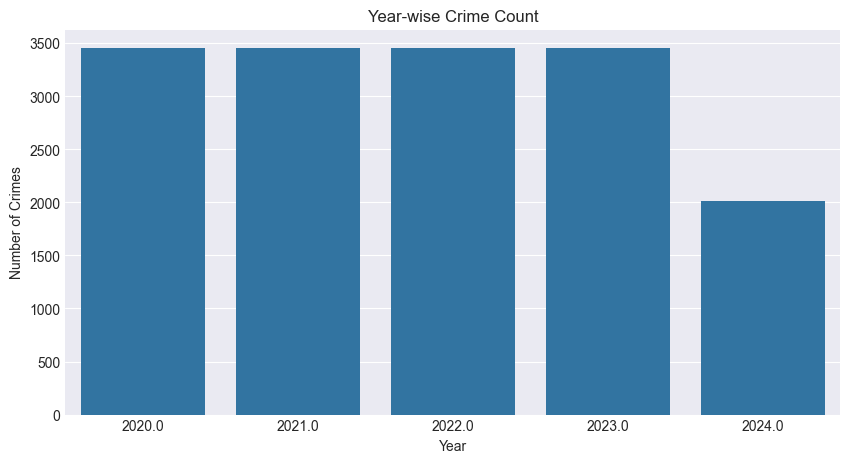

In [ ]:
yearly_crime = df['year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.barplot(x=yearly_crime.index, y=yearly_crime.values)
plt.title("Year-wise Crime Count")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.show()


**Insight:** The bar chart shows how crime rates fluctuate by year.  
This helps identify years with unusually high or low crime activity.


In [ ]:
agg = df.groupby(['City', 'Latitude', 'Longitude']).size().reset_index(name='count')

fig = px.scatter_mapbox(
    agg,
    lat="Latitude",
    lon="Longitude",
    size="count",
    size_max=40,
)
fig.update_layout(mapbox_style="open-street-map")
fig.show()

C:\Users\nishi\AppData\Local\Temp\ipykernel_9728\4289864521.py:3: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
# Check the column names in the DataFrame
df.columns

**Insight:** Certain metro cities show a higher number of reported crimes,  
indicating dense population and reporting activity concentration.


C:\Users\nishi\AppData\Local\Temp\ipykernel_19368\237331706.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_crimes.values, y=top_crimes.index, palette='coolwarm')


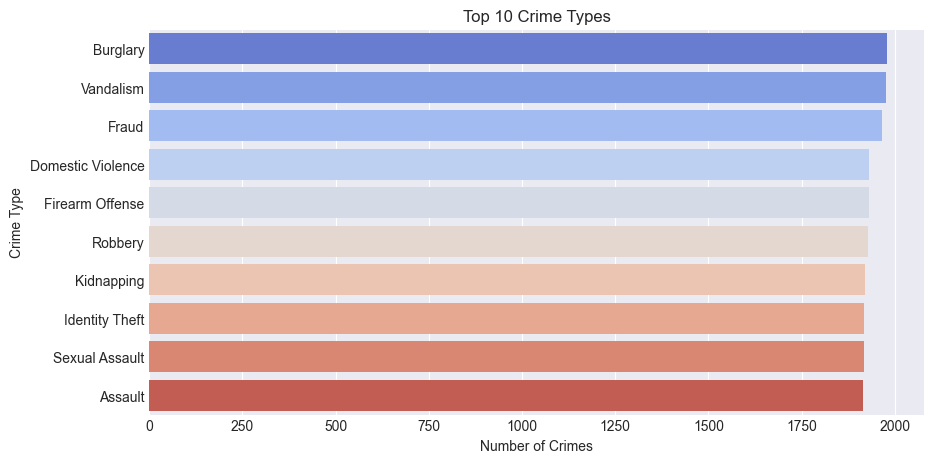

In [ ]:
top_crimes = df['crime_description'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_crimes.values, y=top_crimes.index, palette='coolwarm')
plt.title("Top 10 Crime Types")
plt.xlabel("Number of Crimes")
plt.ylabel("Crime Type")
plt.show()


**Insight:** The dataset highlights the most frequent crime categories,  
providing a focus for law enforcement and awareness campaigns.


C:\Users\nishi\AppData\Local\Temp\ipykernel_19368\528612809.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_count.index, y=gender_count.values, palette='Set2')


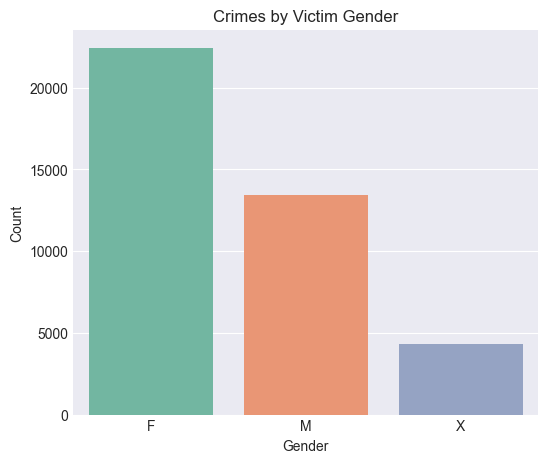

In [ ]:
gender_count = df['victim_gender'].value_counts()

plt.figure(figsize=(6,5))
sns.barplot(x=gender_count.index, y=gender_count.values, palette='Set2')
plt.title("Crimes by Victim Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


**Insight:** Visualizing gender distribution helps understand which group is more often victimized.

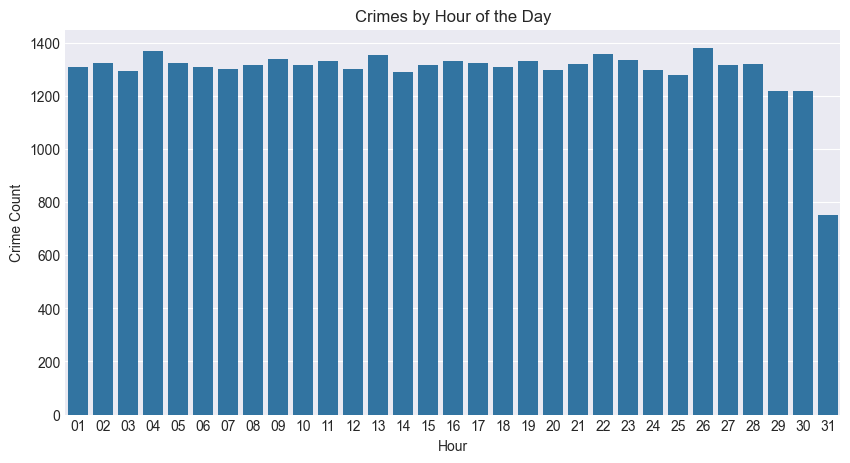

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='hour', order=sorted(df['hour'].unique()))
plt.title("Crimes by Hour of the Day")
plt.xlabel("Hour")
plt.ylabel("Crime Count")
plt.show()


**Insight:** This chart highlights when most crimes occur — for example,  
night-time peaks may indicate unsafe hours for certain areas.


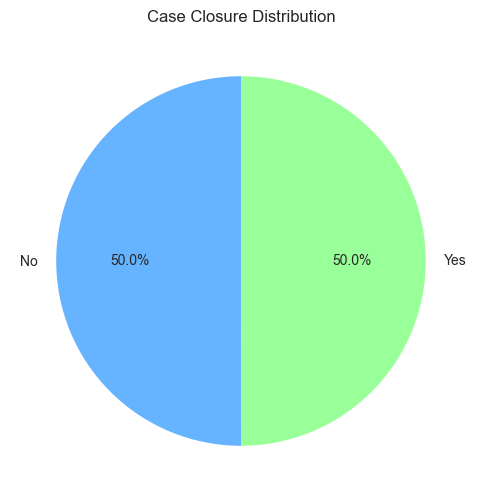

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

case_status = df['case_closed'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(case_status.values, labels=case_status.index, autopct='%1.1f%%', 
        startangle=90, colors=['#66b3ff','#99ff99'])
plt.title('Case Closure Distribution')
plt.show()


**Insight:** The proportion of closed vs open cases helps assess  
the efficiency of the justice process or case follow-up rate.


In [ ]:
df = pd.read_csv("crime_dataset_india.csv", header=None)
df.head()


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,Report Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed
1,1,02-01-2020 00:00,01-01-2020 00:00,01-01-2020 01:11,Ahmedabad,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,No,NaN
2,2,01-01-2020 19:00,01-01-2020 01:00,01-01-2020 06:26,Chennai,128,HOMICIDE,37,M,Poison,Other Crime,9,No,NaN
3,3,02-01-2020 05:00,01-01-2020 02:00,01-01-2020 14:30,Ludhiana,271,KIDNAPPING,48,F,Blunt Object,Other Crime,15,No,NaN
4,4,01-01-2020 05:00,01-01-2020 03:00,01-01-2020 14:46,Pune,170,BURGLARY,49,F,Firearm,Other Crime,1,Yes,29-04-2020 05:00


In [ ]:
# show raw first line(s) to confirm header and delimiter
with open("crime_dataset_india.csv", "rb") as f:
    raw = f.read(4000)   # show first few KB
print(raw[:4000])
# also try reading first text lines (safe)
with open("crime_dataset_india.csv", encoding="utf-8", errors="replace") as f:
    for i, line in enumerate(f):
        print(i, repr(line.strip()))
        if i >= 6:
            break


b'\xef\xbb\xbfReport Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed\r\n1,02-01-2020 00:00,01-01-2020 00:00,01-01-2020 01:11,Ahmedabad,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,No,\r\n2,01-01-2020 19:00,01-01-2020 01:00,01-01-2020 06:26,Chennai,128,HOMICIDE,37,M,Poison,Other Crime,9,No,\r\n3,02-01-2020 05:00,01-01-2020 02:00,01-01-2020 14:30,Ludhiana,271,KIDNAPPING,48,F,Blunt Object,Other Crime,15,No,\r\n4,01-01-2020 05:00,01-01-2020 03:00,01-01-2020 14:46,Pune,170,BURGLARY,49,F,Firearm,Other Crime,1,Yes,29-04-2020 05:00\r\n5,01-01-2020 21:00,01-01-2020 04:00,01-01-2020 16:51,Pune,421,VANDALISM,30,F,Other,Other Crime,18,Yes,08-01-2020 21:00\r\n6,02-01-2020 03:00,01-01-2020 05:00,01-01-2020 17:09,Delhi,442,ASSAULT,16,M,Firearm,Violent Crime,18,Yes,30-03-2020 03:00\r\n7,01-01-2020 16:00,01-01-2020 06:00,01-01-2020 14:08,Chennai,172,VEHICL

In [ ]:
import pandas as pd

# Try comma first
try:
    df = pd.read_csv("crime_dataset_india.csv", encoding="utf-8")
    print("Loaded with utf-8 + comma")
except Exception as e:
    print("comma+utf8 failed:", e)
    df = None

# If header still wrong, try auto-detect delimiter
if df is None or df.columns.tolist()[:6] == [0,1,2,3,4,5]:
    import csv
    import io
    with open("crime_dataset_india.csv", "r", encoding="utf-8", errors="replace") as f:
        sample = f.read(8192)
    sniffer = csv.Sniffer()
    dialect = sniffer.sniff(sample)
    print("Detected delimiter:", repr(dialect.delimiter))
    df = pd.read_csv("crime_dataset_india.csv", sep=dialect.delimiter, encoding="utf-8", engine="python")
    print("Loaded with detected delimiter")


Loaded with utf-8 + comma


In [ ]:
cols = df.columns.tolist()
print("Columns (raw):")
for c in cols:
    print(repr(c))
print("\nFirst 3 rows:")
display(df.head(3))


Columns (raw):
'Report Number'
'Date Reported'
'Date of Occurrence'
'Time of Occurrence'
'City'
'Crime Code'
'Crime Description'
'Victim Age'
'Victim Gender'
'Weapon Used'
'Crime Domain'
'Police Deployed'
'Case Closed'
'Date Case Closed'

First 3 rows:


,Report Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed
0,1,02-01-2020 00:00,01-01-2020 00:00,01-01-2020 01:11,Ahmedabad,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,No,NaN
1,2,01-01-2020 19:00,01-01-2020 01:00,01-01-2020 06:26,Chennai,128,HOMICIDE,37,M,Poison,Other Crime,9,No,NaN
2,3,02-01-2020 05:00,01-01-2020 02:00,01-01-2020 14:30,Ludhiana,271,KIDNAPPING,48,F,Blunt Object,Other Crime,15,No,NaN


In [ ]:
import re
def clean_col(c):
    c = str(c)
    c = c.strip()
    c = c.replace("\ufeff","")      # remove BOM if present
    c = re.sub(r'[^0-9a-zA-Z]+', '_', c).strip('_')
    return c.lower()

df.columns = [clean_col(c) for c in df.columns]
print("Clean columns:", df.columns.tolist())


Clean columns: ['report_number', 'date_reported', 'date_of_occurrence', 'time_of_occurrence', 'city', 'crime_code', 'crime_description', 'victim_age', 'victim_gender', 'weapon_used', 'crime_domain', 'police_deployed', 'case_closed', 'date_case_closed']


In [ ]:
if 'city' not in df.columns:
    print("city not found → assigning column names manually (based on earlier screenshot).")
    names = [
        "report_number","date_reported","date_of_occurrence","time_of_occurrence",
        "city","crime_code","crime_description","victim_age","victim_gender",
        "weapon_used","crime_domain","police_deployed","case_closed","date_case_closed"
    ]
    # reload forcing header=None then set names
    df = pd.read_csv("crime_dataset_india.csv", header=None, encoding="utf-8", sep=None, engine="python")
    df.columns = names[:len(df.columns)]
    print("Assigned names:", df.columns.tolist())
    display(df.head(3))


In [ ]:
df['city'] = df['city'].astype(str).str.strip().str.title()    # consistent formatting

# your city_coords (extend as needed)
city_coords = {
    "Mumbai": [19.0760, 72.8777],
    "Delhi": [28.7041, 77.1025],
    "Bengaluru": [12.9716, 77.5946],
    "Hyderabad": [17.3850, 78.4867],
    "Chennai": [13.0827, 80.2707],
    "Kolkata": [22.5726, 88.3639],
    "Pune": [18.5204, 73.8567],
    "Jaipur": [26.9124, 75.7873],
    "Ahmedabad": [23.0225, 72.5714],
    "Lucknow": [26.8467, 80.9462],
    "Nagpur": [21.1458, 79.0882],
    "Visakhapatnam": [17.6868, 83.2185],
    "Vasai": [19.3919, 72.8397]
}

unique_cities = sorted(df['city'].unique())
print("Unique city sample (first 40):", unique_cities[:40])

unmatched = [c for c in unique_cities if c not in city_coords]
print("Unmatched cities (first 40):", unmatched[:40])


Unique city sample (first 40): ['Agra', 'Ahmedabad', 'Bangalore', 'Bhopal', 'Chennai', 'Delhi', 'Faridabad', 'Ghaziabad', 'Hyderabad', 'Indore', 'Jaipur', 'Kalyan', 'Kanpur', 'Kolkata', 'Lucknow', 'Ludhiana', 'Meerut', 'Mumbai', 'Nagpur', 'Nashik', 'Patna', 'Pune', 'Rajkot', 'Srinagar', 'Surat', 'Thane', 'Varanasi', 'Vasai', 'Visakhapatnam']
Unmatched cities (first 40): ['Agra', 'Bangalore', 'Bhopal', 'Faridabad', 'Ghaziabad', 'Indore', 'Kalyan', 'Kanpur', 'Ludhiana', 'Meerut', 'Nashik', 'Patna', 'Rajkot', 'Srinagar', 'Surat', 'Thane', 'Varanasi']


In [ ]:
city_coords = {
    "Mumbai": [19.0760, 72.8777],
    "Delhi": [28.7041, 77.1025],
    "Bengaluru": [12.9716, 77.5946],      # Your 'Bangalore' will be mapped
    "Bangalore": [12.9716, 77.5946],      # Alias added
    "Hyderabad": [17.3850, 78.4867],
    "Chennai": [13.0827, 80.2707],
    "Kolkata": [22.5726, 88.3639],
    "Pune": [18.5204, 73.8567],
    "Ahmedabad": [23.0225, 72.5714],
    "Lucknow": [26.8467, 80.9462],
    "Nagpur": [21.1458, 79.0882],
    "Visakhapatnam": [17.6868, 83.2185],
    "Vasai": [19.3919, 72.8397],
    
    # Newly added from your unmatched list:
    "Agra": [27.1767, 78.0081],
    "Bhopal": [23.2599, 77.4126],
    "Faridabad": [28.4089, 77.3178],
    "Ghaziabad": [28.6692, 77.4538],
    "Indore": [22.7196, 75.8577],
    "Kalyan": [19.2403, 73.1305],
    "Kanpur": [26.4499, 80.3319],
    "Ludhiana": [30.9010, 75.8573],
    "Meerut": [28.9845, 77.7064],
    "Nashik": [19.9975, 73.7898],
    "Patna": [25.5941, 85.1376],
    "Rajkot": [22.3039, 70.8022],
    "Srinagar": [34.0837, 74.7973],
    "Surat": [21.1702, 72.8311],
    "Thane": [19.2183, 72.9781],
    "Varanasi": [25.3176, 82.9739]
}
df['lat'] = df['city'].map(lambda x: city_coords.get(x, [None, None])[0])
df['lon'] = df['city'].map(lambda x: city_coords.get(x, [None, None])[1])


In [ ]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"

agg = df.groupby(['city', 'lat', 'lon']).size().reset_index(name='count')

fig = px.scatter_mapbox(
    agg,
    lat="lat",
    lon="lon",
    size="count",
    hover_name="city",
    zoom=4,
    height=600,
    color="count",
    size_max=40,
)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(title="Crime Hotspots Across Indian Cities")
fig.show()


KeyError: 'city'

In [ ]:
import folium
from folium.plugins import HeatMap

# Center of India
m = folium.Map(location=[22.9734, 78.6569], zoom_start=5)

# Prepare heatmap data
heat_data = df[['lat','lon']].dropna().values.tolist()

HeatMap(heat_data, radius=15).add_to(m)

m.save("crime_heatmap.html")

from IPython.display import IFrame
m.save("crime_heatmap.html")
IFrame("crime_heatmap.html", width=1000, height=600)


KeyError: "None of [Index(['lat', 'lon'], dtype='object')] are in the [columns]"

In [ ]:
import plotly.express as px

crime_types = sorted(df['crime_description'].unique())

figs = {}

for crime in crime_types:
    subset = df[df['crime_description'] == crime]
    agg = subset.groupby(['city','lat','lon']).size().reset_index(name='count')
    figs[crime] = agg

# create dropdown buttons
buttons = []
for crime in crime_types:
    buttons.append(
        dict(
            method="update",
            label=crime,
            args=[{
                "lat": [figs[crime]['lat']],
                "lon": [figs[crime]['lon']],
                "marker": dict(size=figs[crime]['count'] / 2 + 5)
            }]
        )
    )

# initial figure (first crime type)
initial = crime_types[0]
agg0 = figs[initial]

fig = px.scatter_mapbox(
    agg0,
    lat="lat",
    lon="lon",
    size="count",
    hover_name="city",
    zoom=4,
    height=650
)
fig.update_layout(mapbox_style="open-street-map")

fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            x=0.1,
            y=0.95,
            showactive=True
        )
    ]
)

fig.update_layout(title="Crime Type Filter — Interactive Map")
fig.show()


KeyError: 'crime_description'